# Lecture 01 — Simple Linear Regression

**ISLP Reference:** Chapter 3.1 — Simple Linear Regression  
**Dataset:** La Liga 2015/16 (StatsBomb Open Data)

## Theoretical Context

Simple linear regression models a single predictor $X$ to explain a quantitative response $Y$:

$$Y = \beta_0 + \beta_1 X + \varepsilon$$

Parameters are estimated by **OLS (Ordinary Least Squares)**, which minimises the Residual Sum of Squares (RSS) — the total squared distance between observed and predicted values.

---

### Inference — parameters and reference values

| Parameter | What it is | Reference values |
|---|---|---|
| **β̂₀ (intercept)** | Expected value of Y when X = 0 | Interpret in domain context; not always meaningful |
| **β̂₁ (slope)** | Change in Y associated with a one-unit increase in X | Sign and magnitude must match domain intuition |
| **Standard Error (SE)** | Uncertainty around the estimate of β̂₁ | Smaller is better; SE << \|β̂₁\| indicates a precise estimate |
| **t-statistic** | β̂₁ / SE — how many standard errors the estimate is from zero | \|t\| > 2 ≈ significant at α = 0.05 for large samples |
| **p-value** | Probability of observing this t-statistic if H₀: β₁ = 0 were true | p < 0.05 → significant; p < 0.01 → strong evidence; p < 0.001 → very strong |
| **95% CI for β̂₁** | Interval that contains the true β₁ in 95% of repeated samples | Must exclude 0 to confirm a statistically significant effect |
| **R²** | Fraction of variance in Y explained by the model (0 to 1) | No universal threshold — depends on context; in football, 0.3+ for a single predictor is meaningful |
| **RSE** | Typical prediction error for an individual observation, in the same unit as Y | Lower is better; compare to the mean of Y to assess relative precision |
| **F-statistic** | Ratio of variance explained by the model to residual variance; tests whether the model as a whole is significant | F > 1 means the model explains more than noise; in simple LR, F = t²; p-value of F < 0.05 → model is significant |

---

### Prediction — parameters and reference values

| Parameter | What it is | Reference values |
|---|---|---|
| **Point prediction (ŷ)** | Single expected value of Y for a new observation $x^*$: $\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 x^*$ | Reliable near the centre of the training data; extrapolation beyond observed X is risky |
| **Confidence Interval (CI)** | 95% interval for $E[Y \| X = x^*]$ — uncertainty about the mean response at $x^*$ | Narrows as n grows; narrowest at the mean of X |
| **Prediction Interval (PI)** | 95% interval for a single new observation at $x^*$ — includes both estimation uncertainty and irreducible error ε | Always wider than the CI; cannot shrink below RSE regardless of sample size |

---

### Variable choice & leakage rationale
- **Target — `XG_TOTAL`**: sum of `shot_statsbomb_xg` per team per match — a post-shot xG model that accounts for shot placement, keeper position from the freeze frame, and defenders between shooter and goal. More predictive of actual goals than pre-shot xG.
- **Predictor — `SHOTS_IN_BOX`**: count of shots taken from inside the penalty area (x > 102, 18 < y < 62 in StatsBomb 120×80 pitch coordinates). Chosen because (1) shot location is the strongest determinant of shot quality, (2) it is a pure count measured *before* shot quality is evaluated — no leakage from the post-shot model itself.

**Football application:** do teams that generate more shots from inside the box produce higher xG per match in La Liga 2015/16?

---
## 1 · Imports

In [1]:
# ===================== IMPORTS =====================

# stdlib
import sys
import os

# third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# local
sys.path.append(os.path.join(os.getcwd(), '..'))
from utils.football_helpers import COLORS, SEQUENTIAL_PALETTE, apply_style

apply_style()

---
## 2 · Data Loading

In [2]:
# ===================== DATA LOADING =====================

DATA_PATH = "../data/laliga_2015_16_team_match.csv"

df_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (759, 14)


,team,XG_TOTAL,SHOTS_TOTAL,SHOTS_IN_BOX,SHOTS_ON_TARGET,SHOTS_CLOSE_RANGE,SHOTS_MID_RANGE,SHOTS_HEADER,SHOTS_OPEN_PLAY,SHOTS_UNDER_PRESSURE,SHOTS_FIRST_TIME,DEFENDERS_IN_FF_TOTAL,match_id,match_date
0,Málaga,1.088230,26,10,4,3,16,1,25,2,5,218,3825562,2015-08-21
1,Sevilla,1.414678,10,8,2,5,2,2,10,2,5,77,3825562,2015-08-21
2,Atlético Madrid,0.539486,12,5,3,3,7,1,10,0,6,96,3825563,2015-08-22


In [3]:
# Quick overview of columns
df_raw.dtypes.value_counts()

int64      11
object      2
float64     1
Name: count, dtype: int64

In [4]:
# Print all column names to help with selection
for i, col in enumerate(df_raw.columns):
    print(f"{i:4d}  {col}")

   0  team
   1  XG_TOTAL
   2  SHOTS_TOTAL
   3  SHOTS_IN_BOX
   4  SHOTS_ON_TARGET
   5  SHOTS_CLOSE_RANGE
   6  SHOTS_MID_RANGE
   7  SHOTS_HEADER
   8  SHOTS_OPEN_PLAY
   9  SHOTS_UNDER_PRESSURE
  10  SHOTS_FIRST_TIME
  11  DEFENDERS_IN_FF_TOTAL
  12  match_id
  13  match_date


---
## 3 · Preprocessing

In [5]:
# ===================== VARIABLE SELECTION =====================

TARGET    = "XG_TOTAL"
PREDICTOR = "SHOTS_IN_BOX"

df = df_raw[[TARGET, PREDICTOR]].dropna().copy()

print(f"Rows: {len(df)}")
df.describe()

Rows: 759


,XG_TOTAL,SHOTS_IN_BOX
count,759.000000,759.000000
mean,1.290876,7.366271
std,0.816635,3.741689
min,0.085537,0.000000
25%,0.673852,5.000000
50%,1.135265,7.000000
75%,1.691808,10.000000
max,5.143205,24.000000


---
## 4 · Modelling

### 4.1 · Model Fitting

In [6]:
# ===================== FIT OLS MODEL =====================

X = sm.add_constant(df[[PREDICTOR]])
y = df[TARGET]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               XG_TOTAL   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     958.7
Date:                Mon, 11 May 2026   Prob (F-statistic):          1.23e-136
Time:                        16:26:15   Log-Likelihood:                -612.21
No. Observations:                 759   AIC:                             1228.
Df Residuals:                     757   BIC:                             1238.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0891      0.044      2.047   

### 4.2 · Inference

Extracting and interpreting each diagnostic metric produced by the model.

In [7]:
# ===================== INFERENCE =====================

b0, b1 = model.params["const"], model.params[PREDICTOR]
se_b1  = model.bse[PREDICTOR]
t_b1   = model.tvalues[PREDICTOR]
p_b1   = model.pvalues[PREDICTOR]
ci_b1  = model.conf_int().loc[PREDICTOR]
rse    = np.sqrt(model.mse_resid)
r2     = model.rsquared
f_stat = model.fvalue
f_p    = model.f_pvalue

print("=" * 52)
print("  COEFFICIENTS")
print("=" * 52)
print(f"  β̂₀  (intercept) = {b0:.4f}")
print(f"  β̂₁  ({PREDICTOR})")
print(f"       estimate   = {b1:.4f}")
print(f"       std error  = {se_b1:.4f}")
print(f"       t-stat     = {t_b1:.3f}")
print(f"       p-value    = {p_b1:.2e}")
print(f"       95% CI     = [{ci_b1[0]:.4f}, {ci_b1[1]:.4f}]")
print()
print("=" * 52)
print("  MODEL QUALITY")
print("=" * 52)
print(f"  R²         = {r2:.4f}  ({r2*100:.1f}% of xG variance explained)")
print(f"  RSE        = {rse:.4f} xG  (typical prediction error)")
print(f"  F-statistic= {f_stat:.1f}  (p = {f_p:.2e})")

  COEFFICIENTS
  β̂₀  (intercept) = 0.0891
  β̂₁  (SHOTS_IN_BOX)
       estimate   = 0.1631
       std error  = 0.0053
       t-stat     = 30.963
       p-value    = 1.23e-136
       95% CI     = [0.1528, 0.1735]

  MODEL QUALITY
  R²         = 0.5588  (55.9% of xG variance explained)
  RSE        = 0.5428 xG  (typical prediction error)
  F-statistic= 958.7  (p = 1.23e-136)


### 4.3 · Prediction

Three levels of output:
- **Point prediction**: single expected value $\hat{Y}$
- **Confidence Interval**: uncertainty around the *mean response* at $x^*$
- **Prediction Interval**: uncertainty for a *single new observation* (wider — includes irreducible error $\varepsilon$)

In [8]:
# ===================== PREDICTION =====================

# Grid across the observed range
x_grid = pd.DataFrame({"const": 1.0, PREDICTOR: np.arange(0, 25)})
pred_grid = model.get_prediction(x_grid).summary_frame(alpha=0.05)

# --- Point prediction for specific match scenarios ---
scenarios = {
    "Low volume  (3 box shots)":    3,
    "Average match (7 box shots)":  7,
    "High volume (13 box shots)":  13,
}

print(f"{'Scenario':<32} {'XG_TOTAL':>10} {'CI lower':>10} {'CI upper':>10} {'PI lower':>10} {'PI upper':>10}")
print("-" * 84)

for label, shots in scenarios.items():
    x_new = pd.DataFrame({"const": [1.0], PREDICTOR: [shots]})
    p = model.get_prediction(x_new).summary_frame(alpha=0.05)
    print(
        f"{label:<32}"
        f"{p['mean'].iloc[0]:>10.3f}"
        f"{p['mean_ci_lower'].iloc[0]:>10.3f}"
        f"{p['mean_ci_upper'].iloc[0]:>10.3f}"
        f"{p['obs_ci_lower'].iloc[0]:>10.3f}"
        f"{p['obs_ci_upper'].iloc[0]:>10.3f}"
    )

Scenario                           XG_TOTAL   CI lower   CI upper   PI lower   PI upper
------------------------------------------------------------------------------------
Low volume  (3 box shots)            0.579     0.519     0.638    -0.489     1.646
Average match (7 box shots)          1.231     1.192     1.270     0.165     2.297
High volume (13 box shots)           2.210     2.140     2.280     1.142     3.278


---
## 5 · Visualisations

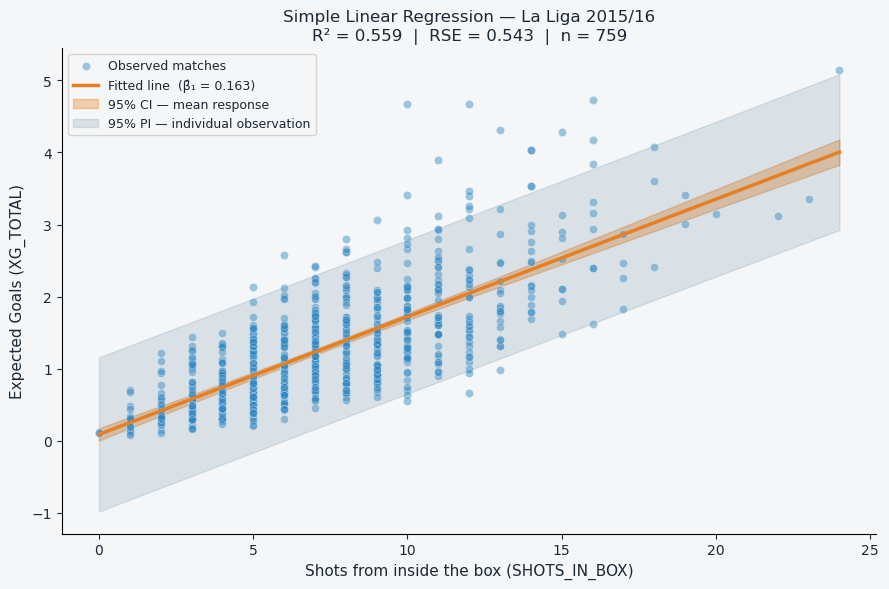

In [9]:
# ===================== SCATTER + REGRESSION LINE + CI + PI =====================

apply_style()
fig, ax = plt.subplots(figsize=(9, 6))

# Observed data
ax.scatter(
    df[PREDICTOR], df[TARGET],
    color=COLORS["secondary"], alpha=0.45, s=35,
    edgecolors="white", linewidth=0.4,
    label="Observed matches", zorder=2,
)

# Regression line
ax.plot(
    x_grid[PREDICTOR], pred_grid["mean"],
    color=COLORS["accent"], linewidth=2.5,
    label=f"Fitted line  (β̂₁ = {b1:.3f})", zorder=3,
)

# 95% Confidence Interval (mean response)
ax.fill_between(
    x_grid[PREDICTOR], pred_grid["mean_ci_lower"], pred_grid["mean_ci_upper"],
    alpha=0.35, color=COLORS["accent"],
    label="95% CI — mean response",
)

# 95% Prediction Interval (individual observation)
ax.fill_between(
    x_grid[PREDICTOR], pred_grid["obs_ci_lower"], pred_grid["obs_ci_upper"],
    alpha=0.12, color=COLORS["primary"],
    label="95% PI — individual observation",
)

ax.set_xlabel("Shots from inside the box (SHOTS_IN_BOX)", fontsize=11)
ax.set_ylabel("Expected Goals (XG_TOTAL)", fontsize=11)
ax.set_title(
    f"Simple Linear Regression — La Liga 2015/16\n"
    f"R² = {r2:.3f}  |  RSE = {rse:.3f}  |  n = {len(df)}",
    fontsize=12,
)
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

---
## 6 · Interpretation

### 6.1 Inference

**β̂₀ = 0.0891 — Intercept**  
A team with zero box shots is expected to generate 0.09 xG — a near-zero baseline, as all remaining xG would come from rare long-range or set-piece attempts. In practice this scenario hardly occurs, but the intercept confirms the model is well-calibrated at the origin.

**β̂₁ = 0.1631 — Slope**  
Each additional shot from inside the box adds **+0.16 xG**. A team that generates 13 box shots instead of 7 is expected to produce ~0.98 more xG — almost one full goal-scoring chance gained simply from shot location.

**Standard Error = 0.0053**  
The estimation uncertainty around β̂₁ is very small. With 759 observations, the model pinpoints the effect of box shots with high precision — less than 0.006 xG per shot of estimation error.

**t-statistic = 30.96 | p-value ≈ 1.23e-136**  
We decisively reject H₀: β₁ = 0. The probability of observing this association by chance alone is astronomically small. Box shots from inside the area are a statistically significant predictor of xG in La Liga 2015/16.

**95% Confidence Interval for β̂₁ = [0.1528, 0.1735]**  
The true effect of one extra box shot on XG_TOTAL is between 0.15 and 0.17 with 95% confidence. The interval excludes zero and is narrow — the estimate is stable across the full La Liga season.

**R² = 0.5588**  
Box shots alone explain **55.9% of the match-to-match variance** in xG — a strong result for a single predictor. The remaining 44% reflects variation in shot quality: not all box shots are equal, with headers, close-range efforts, and shots under pressure generating different xG values for the same location count.

**RSE = 0.5428 xG**  
The typical prediction error for an individual match is ±0.54 xG. Since the average XG_TOTAL in La Liga 2015/16 is ~1.29, this represents a relative error of ~42%. The model is useful for comparing team profiles across a season, but individual match forecasts carry meaningful uncertainty.

**F-statistic = 958.7**  
The overall model is highly significant. The variation explained by box shots is 959× larger than what would be expected from a model with no predictive power.

---

### 6.2 Prediction

**Low volume — 3 box shots → XG_TOTAL = 0.579 | CI = [0.519, 0.638] | PI = [-0.489, 1.646]**  
Teams generating only 3 box shots produce, on average, 0.58 xG — less than half the La Liga mean. The CI confirms the average is reliably between 0.52 and 0.64. The wide PI reflects that even with few box shots, a single well-placed attempt near goal can inflate xG.

**Average match — 7 box shots → XG_TOTAL = 1.231 | CI = [1.192, 1.270] | PI = [0.165, 2.297]**  
At the La Liga average (7 box shots), the expected xG is 1.23. The CI is the tightest of the three scenarios — 7 is near the centre of the data, where OLS estimates are most precise. The PI remains wide: individual matches at this volume can realistically fall anywhere from 0.17 to 2.30 xG.

**High volume — 13 box shots → XG_TOTAL = 2.210 | CI = [2.140, 2.280] | PI = [1.142, 3.278]**  
A dominant attacking performance. The model expects 2.21 xG — nearly two clear goal-scoring chances. Crucially, the PI lower bound is now clearly positive (1.14), confirming that teams generating this volume of box shots will always produce meaningful xG, even in their worst attacking displays.

**CI vs PI — key distinction**  
The CI answers *"where is the average XG_TOTAL for teams with X box shots?"* and narrows as sample size grows. The PI answers *"where will a single match land?"* and cannot shrink below the RSE (0.54 xG) regardless of sample size. For La Liga analysis: use the CI to compare team profiles over the season; use the PI as the honest range for any single-match forecast.

---
## 7 · Conclusion

Box shots are a statistically significant predictor of xG in La Liga 2015/16 (β̂₁ = 0.16, p ≈ 0), explaining **56% of match-to-match variance** — a strong signal for a single predictor. This is notably higher than typical results in other leagues, suggesting La Liga 2015/16 (featuring Barcelona and Real Madrid at their peak) showed a particularly tight link between penalty-area activity and chance quality.

The RSE of 0.54 xG limits single-match forecasting, making the model more suitable for profiling teams across a season than for game-by-game prediction.

The natural next step is multiple linear regression, adding predictors that capture *how* chances are created — not just where shots are taken from.